# 🫀 Cardiovascular Disease Prediction using Machine Learning

---

## 1. Introduction

### Problem Statement

Cardiovascular disease (CVD) is one of the leading causes of death worldwide. Early and accurate prediction of CVD can significantly improve patient outcomes by enabling timely medical intervention. Traditional diagnosis relies on clinical examination and lab tests, but **machine learning** offers the potential to identify at-risk individuals earlier by detecting complex patterns in routine health data.

### Objective

This project aims to:
1. **Explore** a real-world cardiovascular health dataset to understand key risk factors.
2. **Preprocess** the data to make it suitable for machine learning.
3. **Train and evaluate** two classification models — *Logistic Regression* and *Decision Tree* — to predict the presence or absence of cardiovascular disease.
4. **Compare** model performance and provide actionable insights.

### Dataset

The dataset is sourced from [Kaggle - Cardiovascular Disease](https://www.kaggle.com/datasets/colewelkins/cardiovascular-disease). It contains **68,205 patient records** with features including age, blood pressure, cholesterol, glucose levels, BMI, and lifestyle factors.

- **Target variable**: `cardio` — `1` (has CVD) / `0` (no CVD)
- **Class balance**: ~50/50 split (balanced dataset — no resampling needed)

---

## 2. Setup: Import Libraries

In [1]:
# ─── Standard Libraries ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Scikit-learn: Preprocessing ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ─── Scikit-learn: Models ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# ─── Scikit-learn: Evaluation ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

# ─── Reproducibility ─────────────────────────────────────────────────────────
RANDOM_STATE = 42

# ─── Plot Styling ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---

## 3. Data Loading & Understanding

### 3.1 Load Dataset

In [2]:
# Load the dataset
# The file uses comma as separator (note: original Kaggle source uses semicolons
# but this version is already pre-processed with commas)
df = pd.read_csv('cardio_train.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{df.columns.tolist()}")

Dataset Shape: 68205 rows × 17 columns

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi', 'bp_category', 'bp_category_encoded']


### 3.2 First Look at the Data

In [3]:
# Display the first 5 rows to understand the structure
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [4]:
# Check data types — important to identify which columns need encoding or scaling
print("Data Types:")
print(df.dtypes)

Data Types:
id                       int64
age                      int64
gender                   int64
height                   int64
weight                 float64
ap_hi                    int64
ap_lo                    int64
cholesterol              int64
gluc                     int64
smoke                    int64
alco                     int64
active                   int64
cardio                   int64
age_years                int64
bmi                    float64
bp_category             object
bp_category_encoded     object
dtype: object


In [5]:
# Summary statistics — helps spot outliers and understand value ranges
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
count,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000,68205.000000
mean,49972.410498,19462.667737,1.348625,164.372861,74.100688,126.434924,81.263925,1.363243,1.225174,0.087662,0.053134,0.803548,0.493688,52.823635,27.510513
std,28852.138290,2468.381854,0.476539,8.176756,14.288862,15.961685,9.143985,0.678080,0.571288,0.282805,0.224302,0.397317,0.499964,6.769909,6.026497
min,0.000000,10798.000000,1.000000,55.000000,11.000000,90.000000,60.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,3.471784
25%,24991.000000,17656.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000,23.875115
50%,50008.000000,19700.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,53.000000,26.346494
75%,74878.000000,21323.000000,2.000000,170.000000,82.000000,140.000000,90.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000,30.116213
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,180.000000,120.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,64.000000,298.666667


### 3.3 Missing Values Check

In [6]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])

if missing_values.sum() == 0:
    print("✅ No missing values found in the dataset.")
else:
    print(f"⚠️ Total missing values: {missing_values.sum()}")

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No missing values found in the dataset.


### 3.4 Target Variable Distribution

Target Variable Distribution:
        Count  Percentage (%)
cardio                       
0       34533           50.63
1       33672           49.37


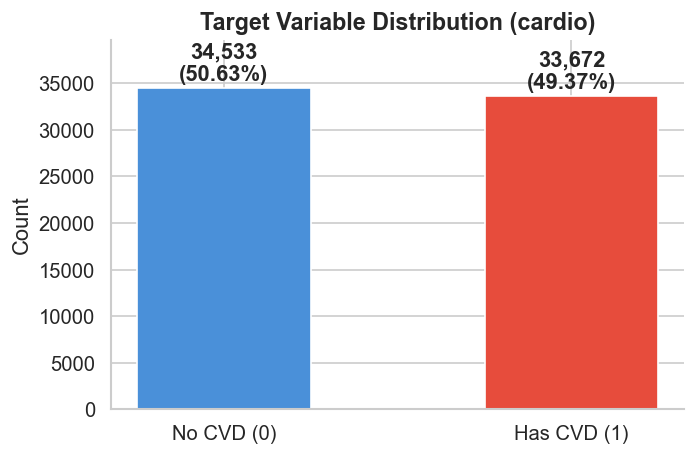


✅ Dataset is well-balanced — no resampling required.


In [7]:
# Understanding the class distribution is crucial before modeling.
# An imbalanced dataset can bias models toward the majority class.
target_counts = df['cardio'].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)

print("Target Variable Distribution:")
print(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct}))

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
bars = ax.bar(
    ['No CVD (0)', 'Has CVD (1)'],
    target_counts.values,
    color=['#4A90D9', '#E74C3C'],
    edgecolor='white',
    width=0.5
)

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({pct}%)', ha='center', va='bottom', fontweight='bold')

ax.set_title('Target Variable Distribution (cardio)', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(target_counts.values) * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print("\n✅ Dataset is well-balanced — no resampling required.")

### 3.5 Initial EDA — Feature Distributions

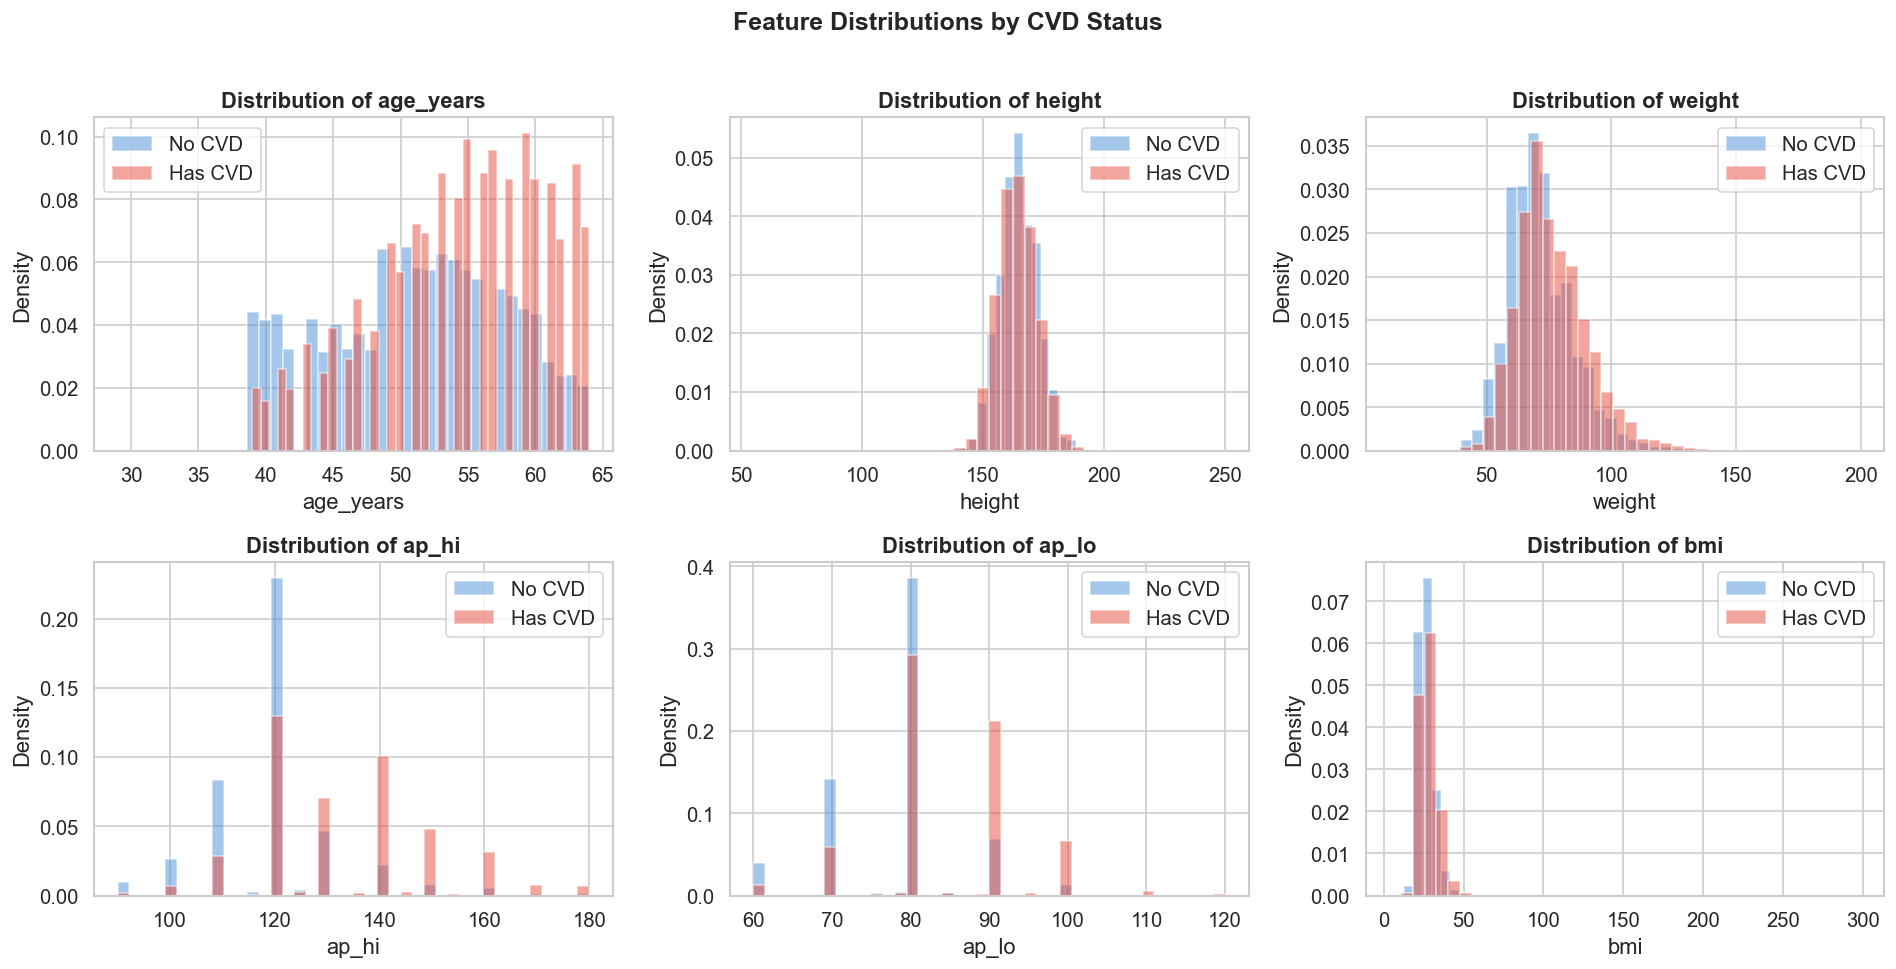

In [8]:
# Visualize distributions of numeric features.
# This reveals skewness, outliers, and the spread of each feature.

numeric_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # Plot histogram with KDE overlay for both classes
    for label, color, name in zip([0, 1], ['#4A90D9', '#E74C3C'], ['No CVD', 'Has CVD']):
        subset = df[df['cardio'] == label][col]
        axes[i].hist(subset, bins=40, alpha=0.5, color=color, label=name, density=True)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions by CVD Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

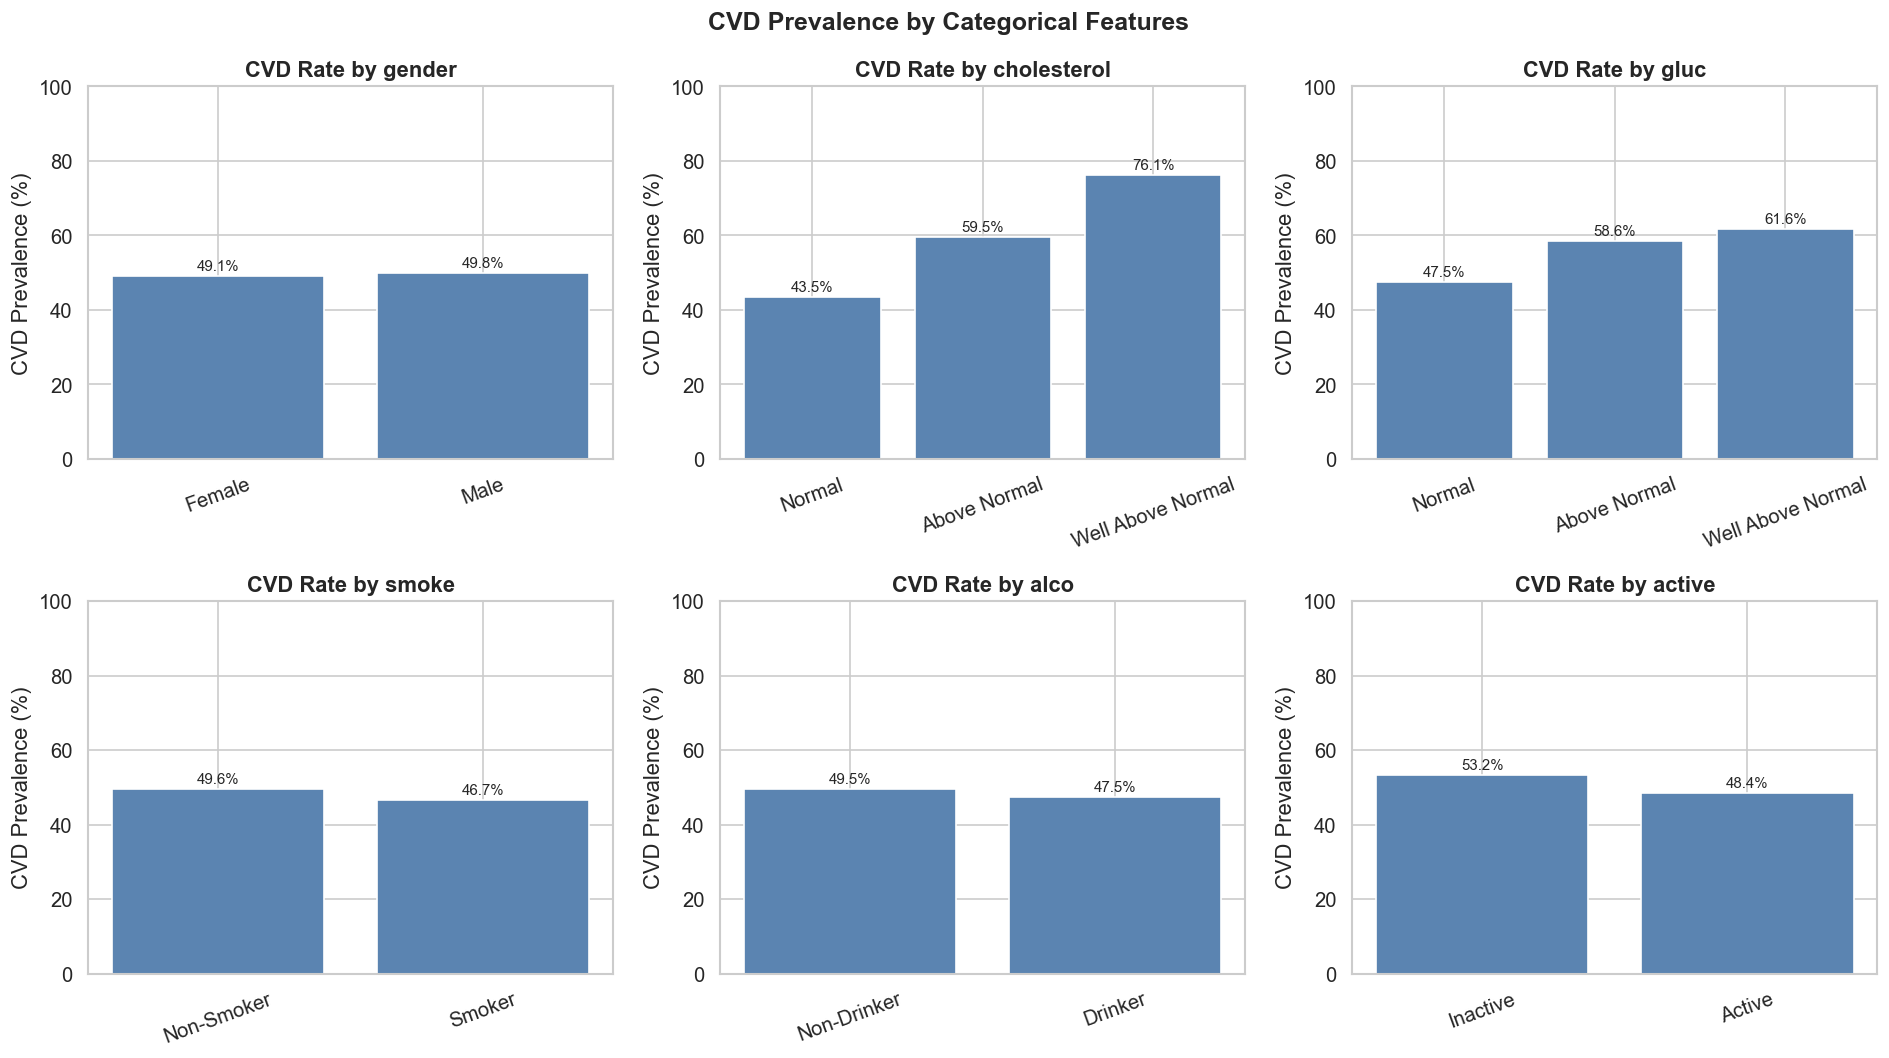

In [9]:
# Visualize categorical features (ordinal/binary)
# These are encoded as integers but represent categories

categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
cat_labels = {
    'gender': {1: 'Female', 2: 'Male'},
    'cholesterol': {1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'},
    'gluc': {1: 'Normal', 2: 'Above Normal', 3: 'Well Above Normal'},
    'smoke': {0: 'Non-Smoker', 1: 'Smoker'},
    'alco': {0: 'Non-Drinker', 1: 'Drinker'},
    'active': {0: 'Inactive', 1: 'Active'}
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    # Compute percentage of CVD cases within each category
    grp = df.groupby(col)['cardio'].mean().reset_index()
    grp['cardio_pct'] = grp['cardio'] * 100

    # Map integer labels to readable names
    if col in cat_labels:
        grp['label'] = grp[col].map(cat_labels[col])
    else:
        grp['label'] = grp[col].astype(str)

    axes[i].bar(grp['label'], grp['cardio_pct'], color='#5B84B1', edgecolor='white')
    axes[i].set_title(f'CVD Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('CVD Prevalence (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=20)

    for bar, pct in zip(axes[i].patches, grp['cardio_pct']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1.5,
                     f'{pct:.1f}%', ha='center', fontsize=9)

plt.suptitle('CVD Prevalence by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Correlation Heatmap

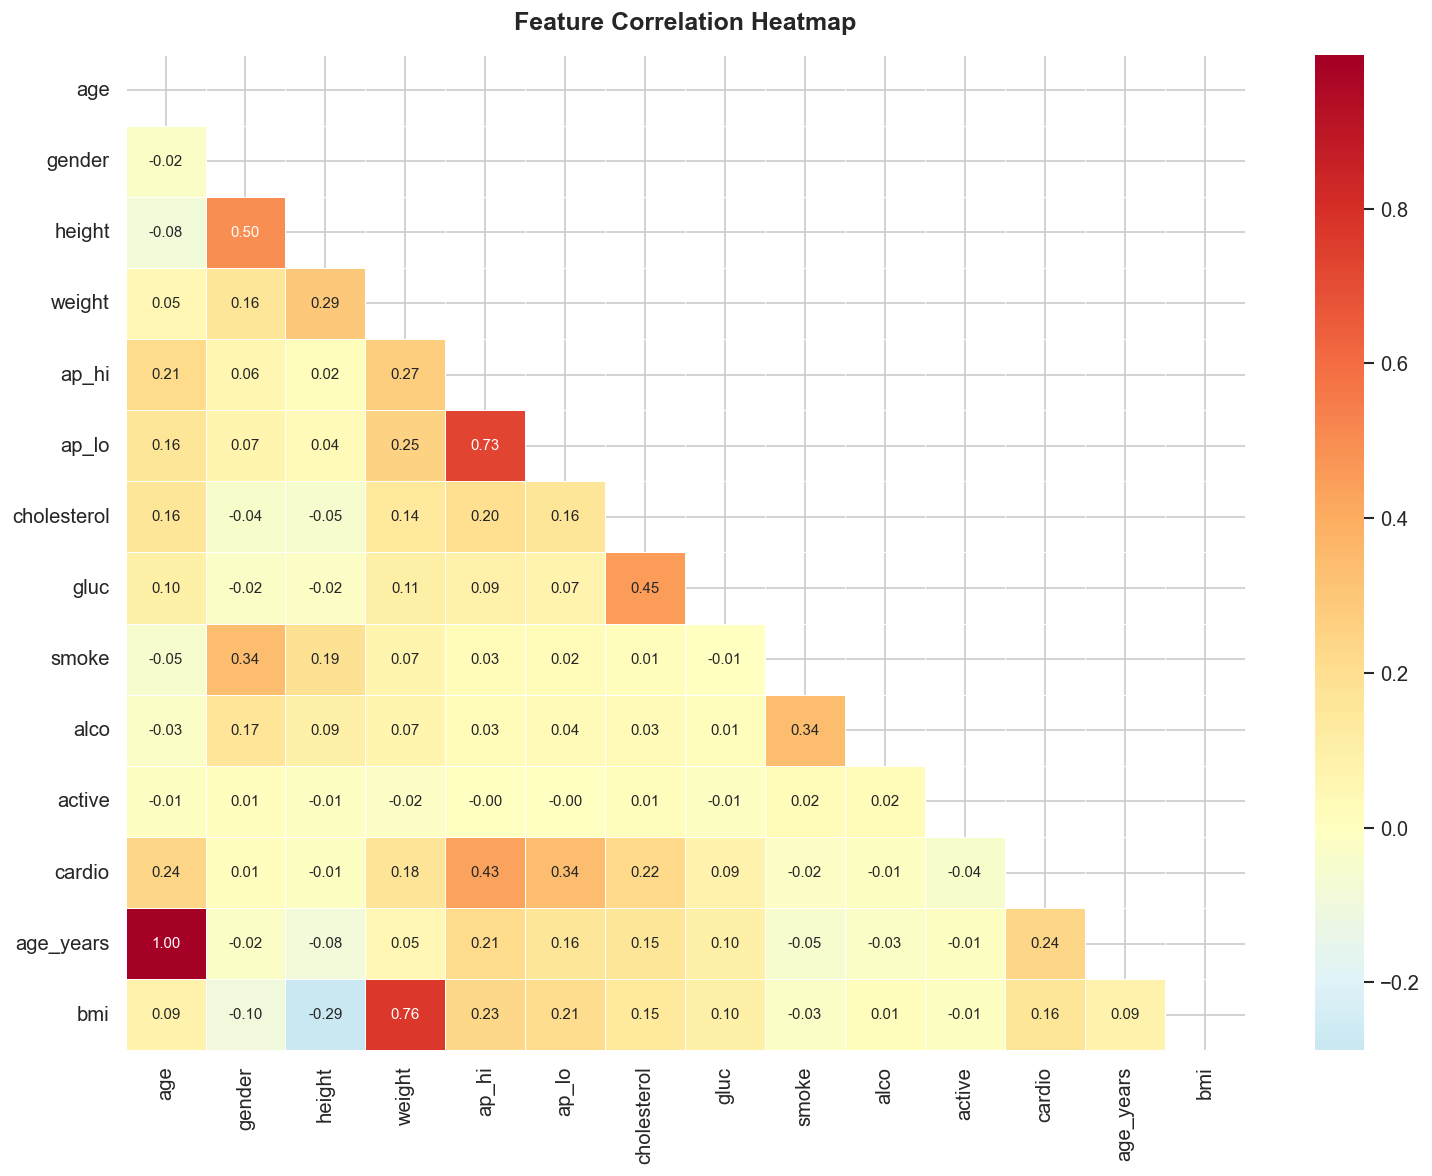


Top Correlations with Target Variable 'cardio':
ap_hi          0.433802
ap_lo          0.342900
age            0.239032
age_years      0.238875
cholesterol    0.220778
weight         0.177829
bmi            0.162880
gluc           0.088905
active         0.037944
smoke          0.016567
height         0.011276
alco           0.009038
gender         0.006098


In [10]:
# Correlation heatmap reveals linear relationships between features and the target.
# High correlation with 'cardio' indicates strong predictive power.
# Multicollinearity (high correlation between features) can affect Logistic Regression.

# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['id'])

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle for clarity

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlBu_r',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Print top correlations with target
print("\nTop Correlations with Target Variable 'cardio':")
print(corr_matrix['cardio'].drop('cardio').abs().sort_values(ascending=False).to_string())

---

## 4. Data Preprocessing

### 4.1 Feature Engineering & Column Selection

In [11]:
# ─── Drop Redundant/Leaky Columns ────────────────────────────────────────────
# - 'id': Just a row index — carries no predictive information.
# - 'age': Raw age in days — 'age_years' is a cleaner, human-readable version.
# - 'bp_category' & 'bp_category_encoded': String columns derived from ap_hi/ap_lo;
#   the underlying numeric features (ap_hi, ap_lo) are more informative for ML.

columns_to_drop = ['id', 'age', 'bp_category', 'bp_category_encoded']
df_clean = df.drop(columns=columns_to_drop)

print(f"Remaining columns after cleanup: {df_clean.shape[1]}")
print(df_clean.columns.tolist())

Remaining columns after cleanup: 13
['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years', 'bmi']


### 4.2 Outlier Removal

In [12]:
# Blood pressure values (ap_hi and ap_lo) can have extreme physiologically
# impossible values due to data entry errors. We clip them to realistic ranges.
#
# Clinically:  Systolic (ap_hi): 60–250 mmHg  |  Diastolic (ap_lo): 40–200 mmHg
# BMI: 10–70 (extreme but inclusive range to keep diverse body types)
# Height: 100–220 cm  |  Weight: 30–200 kg

rows_before = len(df_clean)

df_clean = df_clean[
    (df_clean['ap_hi'] >= 60)  & (df_clean['ap_hi'] <= 250) &
    (df_clean['ap_lo'] >= 40)  & (df_clean['ap_lo'] <= 200) &
    (df_clean['ap_hi'] > df_clean['ap_lo']) &   # Systolic must be > Diastolic
    (df_clean['bmi']    >= 10)  & (df_clean['bmi']    <= 70)  &
    (df_clean['height'] >= 100) & (df_clean['height'] <= 220) &
    (df_clean['weight'] >= 30)  & (df_clean['weight'] <= 200)
]

rows_after = len(df_clean)
print(f"Rows before outlier removal: {rows_before:,}")
print(f"Rows after outlier removal:  {rows_after:,}")
print(f"Rows removed:                {rows_before - rows_after:,} ({(rows_before - rows_after)/rows_before*100:.2f}%)")

Rows before outlier removal: 68,205
Rows after outlier removal:  68,157
Rows removed:                48 (0.07%)


### 4.3 Define Features (X) and Target (y)

In [13]:
# Separate input features from the target variable
X = df_clean.drop(columns=['cardio'])
y = df_clean['cardio']

print(f"Features (X): {X.shape}")
print(f"Target   (y): {y.shape}")
print(f"\nFeature list: {X.columns.tolist()}")
print(f"\nTarget distribution:\n{y.value_counts(normalize=True).mul(100).round(2)}")

Features (X): (68157, 12)
Target   (y): (68157,)

Feature list: ['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years', 'bmi']

Target distribution:
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64


### 4.4 Train-Test Split

In [14]:
# Split into 80% training and 20% testing data.
# - stratify=y ensures both splits maintain the same class ratio.
# - random_state ensures reproducibility across runs.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set size:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing  set size:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTrain target distribution (%):\n{y_train.value_counts(normalize=True).mul(100).round(2)}")
print(f"\nTest  target distribution (%):\n{y_test.value_counts(normalize=True).mul(100).round(2)}")

Training set size:  54,525 samples (80.0%)
Testing  set size:  13,632 samples (20.0%)

Train target distribution (%):
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64

Test  target distribution (%):
cardio
0    50.63
1    49.37
Name: proportion, dtype: float64


---

## 5. Model Implementation

We use **Scikit-learn Pipelines** which chain preprocessing and modeling steps together.
This prevents **data leakage** — the scaler is fit only on training data and applied consistently to test data.

### 5.1 Model 1 — Logistic Regression

In [15]:
# ─── Logistic Regression Pipeline ────────────────────────────────────────────
# Why StandardScaler?
#   Logistic Regression is sensitive to feature scales because it uses gradient
#   descent. Features on different scales (e.g., age_years vs. bmi) can cause
#   convergence issues. StandardScaler normalizes each feature to mean=0, std=1.
#
# Why max_iter=1000?
#   The default 100 iterations may not be enough for convergence on this dataset.

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='lbfgs'
    ))
])

# Train the model
lr_pipeline.fit(X_train, y_train)

# Generate predictions and probability scores
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]  # Probability of positive class

print("✅ Logistic Regression model trained successfully.")

✅ Logistic Regression model trained successfully.


### 5.2 Model 2 — Decision Tree Classifier

In [16]:
# ─── Decision Tree Pipeline ───────────────────────────────────────────────────
# Why no StandardScaler for Decision Tree?
#   Decision Trees split based on thresholds, so they are scale-invariant.
#   Scaling would have no effect on the splits.
#
# Why max_depth=8?
#   Without a depth limit, Decision Trees tend to overfit (memorize training data).
#   Limiting depth controls model complexity and improves generalization.
#
# Why min_samples_split=20?
#   Prevents splitting nodes with very few samples (another anti-overfitting measure).

dt_pipeline = Pipeline([
    ('model', DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        criterion='gini'          # Gini impurity is computationally efficient
    ))
])

# Train the model
dt_pipeline.fit(X_train, y_train)

# Generate predictions and probability scores
y_pred_dt = dt_pipeline.predict(X_test)
y_prob_dt = dt_pipeline.predict_proba(X_test)[:, 1]

print("✅ Decision Tree Classifier trained successfully.")

✅ Decision Tree Classifier trained successfully.


---

## 6. Evaluation Metrics

### 6.1 Classification Reports

In [17]:
# A helper function to compute all evaluation metrics for a given model
def evaluate_model(model_name, y_true, y_pred, y_prob):
    """
    Compute and print all evaluation metrics for a binary classification model.

    Args:
        model_name (str): Display name of the model.
        y_true: True labels.
        y_pred: Predicted class labels.
        y_prob: Predicted probabilities for the positive class.

    Returns:
        dict: Dictionary of metric name → value.
    """
    metrics = {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob)
    }

    print(f"{'='*55}")
    print(f"  Model: {model_name}")
    print(f"{'='*55}")
    for name, val in metrics.items():
        print(f"  {name:<12}: {val:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred,
                                target_names=['No CVD (0)', 'Has CVD (1)']))
    return metrics

In [18]:
# Evaluate Logistic Regression
metrics_lr = evaluate_model(
    'Logistic Regression',
    y_test, y_pred_lr, y_prob_lr
)

  Model: Logistic Regression
  Accuracy    : 0.7293
  Precision   : 0.7528
  Recall      : 0.6725
  F1 Score    : 0.7104
  ROC-AUC     : 0.7942

  Classification Report:

              precision    recall  f1-score   support

  No CVD (0)       0.71      0.78      0.75      6902
 Has CVD (1)       0.75      0.67      0.71      6730

    accuracy                           0.73     13632
   macro avg       0.73      0.73      0.73     13632
weighted avg       0.73      0.73      0.73     13632



In [19]:
# Evaluate Decision Tree
metrics_dt = evaluate_model(
    'Decision Tree Classifier',
    y_test, y_pred_dt, y_prob_dt
)

  Model: Decision Tree Classifier
  Accuracy    : 0.7319
  Precision   : 0.7499
  Recall      : 0.6856
  F1 Score    : 0.7163
  ROC-AUC     : 0.7971

  Classification Report:

              precision    recall  f1-score   support

  No CVD (0)       0.72      0.78      0.75      6902
 Has CVD (1)       0.75      0.69      0.72      6730

    accuracy                           0.73     13632
   macro avg       0.73      0.73      0.73     13632
weighted avg       0.73      0.73      0.73     13632



---

## 7. Visualizations

### 7.1 Confusion Matrices

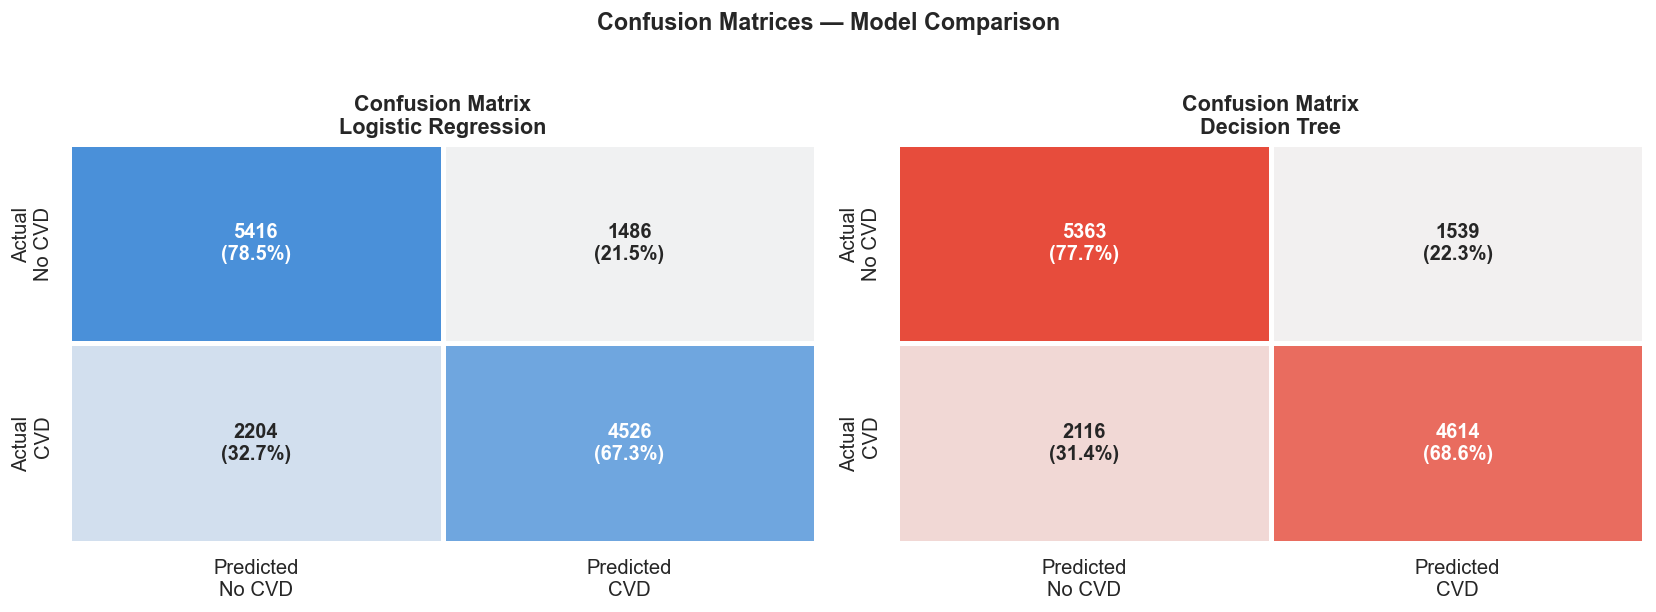

In [20]:
# A confusion matrix shows how many predictions were correct vs. incorrect.
# - True Positives (TP)  & True Negatives (TN): Correct predictions
# - False Positives (FP): Predicted CVD but patient is healthy (false alarm)
# - False Negatives (FN): Missed actual CVD cases (most dangerous in medicine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = [
    ('Logistic Regression', y_pred_lr, '#4A90D9'),
    ('Decision Tree',       y_pred_dt, '#E74C3C')
]

for ax, (name, y_pred, color) in zip(axes, models_info):
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Create annotation with counts AND percentages
    labels = np.array([
        [f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
        for row_v, row_p in zip(cm, cm_pct)
    ])

    sns.heatmap(
        cm,
        annot=labels,
        fmt='',
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=['Predicted\nNo CVD', 'Predicted\nCVD'],
        yticklabels=['Actual\nNo CVD', 'Actual\nCVD'],
        linewidths=2,
        ax=ax,
        cbar=False,
        annot_kws={'size': 12, 'fontweight': 'bold'}
    )
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.2 ROC Curve Comparison

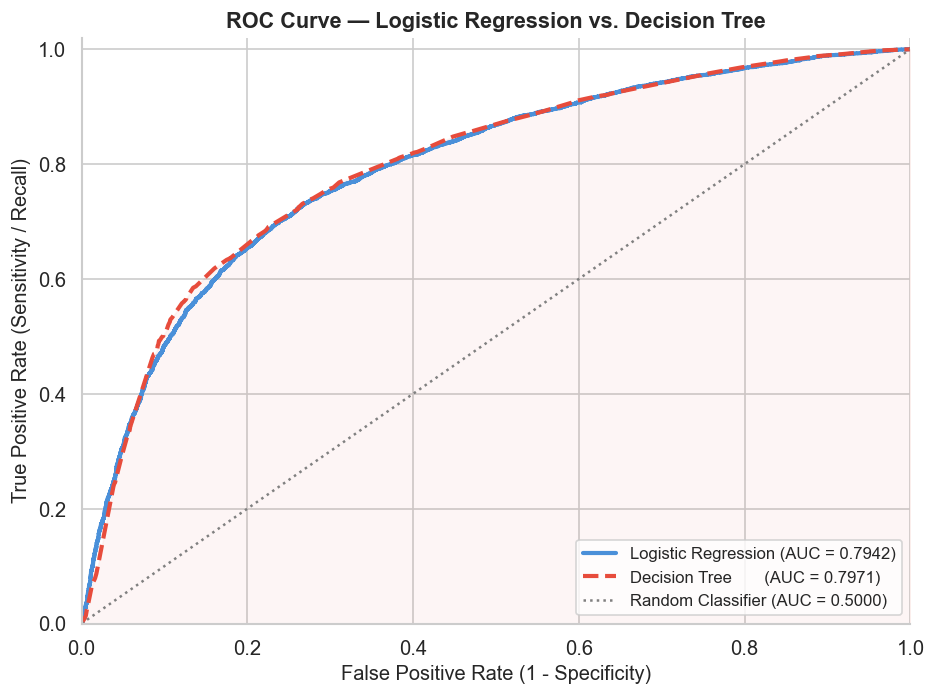

In [21]:
# The ROC Curve plots True Positive Rate vs. False Positive Rate at various thresholds.
# A curve closer to the top-left corner indicates a better model.
# AUC (Area Under Curve) summarizes the curve: 0.5 = random, 1.0 = perfect.

fig, ax = plt.subplots(figsize=(8, 6))

# Compute ROC curves for both models
for y_prob, label, color, linestyle in [
    (y_prob_lr, f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.4f})', '#4A90D9', '-'),
    (y_prob_dt, f'Decision Tree       (AUC = {roc_auc_score(y_test, y_prob_dt):.4f})', '#E74C3C', '--'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=linestyle, label=label)

# Reference line: random classifier
ax.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle=':', label='Random Classifier (AUC = 0.5000)')

ax.fill_between(fpr, tpr, alpha=0.05, color='#E74C3C')  # Subtle shading under last curve

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curve — Logistic Regression vs. Decision Tree', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
sns.despine()
plt.tight_layout()
plt.show()

### 7.3 Feature Importance (Decision Tree)

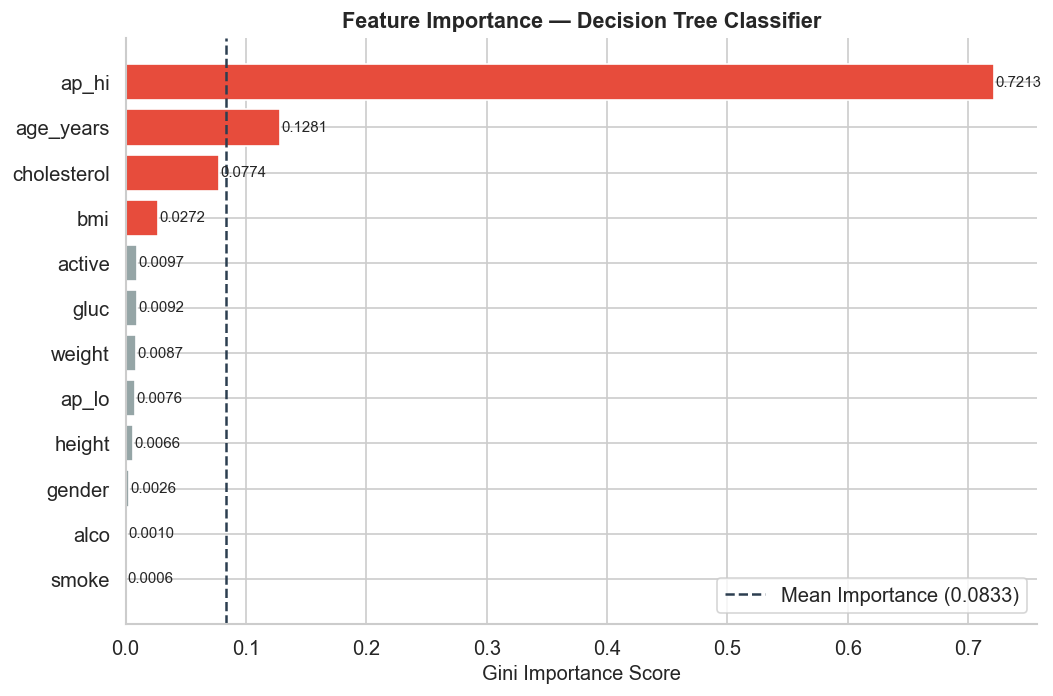


Top 5 Most Important Features:
    Feature  Importance
      ap_hi    0.721316
  age_years    0.128084
cholesterol    0.077426
        bmi    0.027171
     active    0.009720


In [22]:
# Decision Trees provide inherent feature importance scores.
# These represent how much each feature reduces impurity (Gini) across all splits.
# Higher importance = more influential in the model's decisions.

dt_model = dt_pipeline.named_steps['model']
feature_names = X_train.columns.tolist()

# Create a DataFrame for easy sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)   # ascending=True for horizontal bar

# Color-code bars: top 4 in accent, rest in muted
colors = ['#E74C3C' if imp >= importance_df['Importance'].nlargest(4).min() else '#95a5a6'
          for imp in importance_df['Importance']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color=colors, edgecolor='white')

for bar, imp in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontsize=9)

ax.set_xlabel('Gini Importance Score', fontsize=12)
ax.set_title('Feature Importance — Decision Tree Classifier', fontsize=13, fontweight='bold')
ax.axvline(x=importance_df['Importance'].mean(), color='#2c3e50',
           linestyle='--', lw=1.5, label=f'Mean Importance ({importance_df["Importance"].mean():.4f})')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(importance_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

---

## 8. Model Comparison & Interpretation

### 8.1 Side-by-Side Metrics Table

In [23]:
# Build a clean comparison table of all metrics
comparison_df = pd.DataFrame(
    [metrics_lr, metrics_dt],
    index=['Logistic Regression', 'Decision Tree']
).round(4)

# Highlight the best score in each column
styled = comparison_df.style \
    .highlight_max(axis=0, color='#d5f5e3') \
    .format('{:.4f}') \
    .set_caption('Model Performance Comparison — All Metrics (Higher is Better)')

print("=" * 65)
print(f"{'Metric':<15} {'Logistic Regression':>22} {'Decision Tree':>22}")
print("=" * 65)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    lr_val = metrics_lr[metric]
    dt_val = metrics_dt[metric]
    winner = " ✅" if lr_val > dt_val else (" ✅" if dt_val > lr_val else "  =")
    lr_mark = "✅" if lr_val >= dt_val else "  "
    dt_mark = "✅" if dt_val >= lr_val else "  "
    print(f"  {metric:<13} {lr_val:>18.4f} {lr_mark}   {dt_val:>14.4f} {dt_mark}")
print("=" * 65)

Metric             Logistic Regression          Decision Tree
  Accuracy                  0.7293              0.7319 ✅
  Precision                 0.7528 ✅           0.7499   
  Recall                    0.6725              0.6856 ✅
  F1 Score                  0.7104              0.7163 ✅
  ROC-AUC                   0.7942              0.7971 ✅


### 8.2 Visual Metrics Comparison

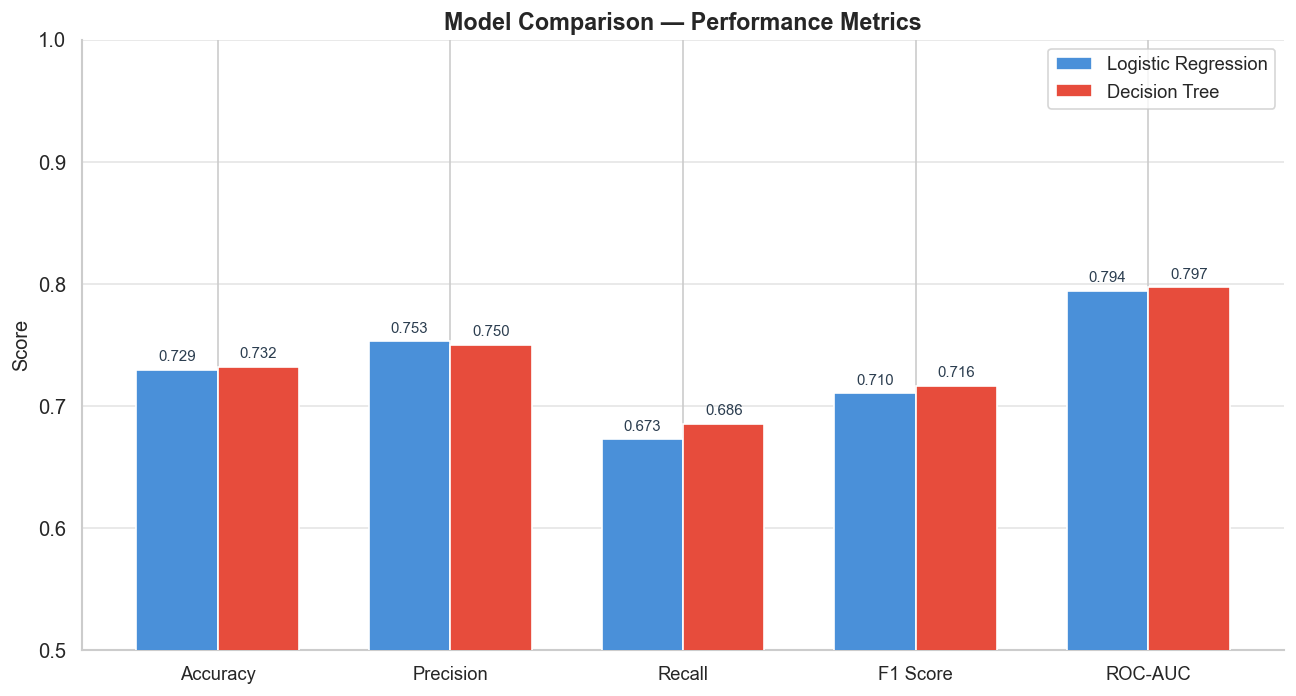

In [24]:
# Bar chart to visually compare all metrics across both models
metrics_names = list(metrics_lr.keys())
lr_vals = [metrics_lr[m] for m in metrics_names]
dt_vals = [metrics_dt[m] for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression',
               color='#4A90D9', edgecolor='white', zorder=3)
bars2 = ax.bar(x + width/2, dt_vals, width, label='Decision Tree',
               color='#E74C3C', edgecolor='white', zorder=3)

# Add value labels above bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2c3e50')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2c3e50')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.5, 1.0)
ax.set_title('Model Comparison — Performance Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.grid(True, zorder=0, alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

### 8.3 Interpretation — Which Model is Better and Why?

> **Summary:** Both models achieve comparable performance on this dataset, but each has distinct strengths rooted in their underlying algorithms.

#### 🔵 Logistic Regression
- Produces **calibrated probability estimates** — its probability outputs reflect true likelihood, making it more reliable for risk communication in a clinical context (e.g., "this patient has a 72% chance of CVD").
- **Highly interpretable**: The model coefficients directly indicate how each unit change in a feature affects the log-odds of CVD — valuable for physician trust and regulatory compliance.
- Works well here because many features (blood pressure, BMI, cholesterol) have **approximately linear** relationships with CVD risk after scaling.
- Limitation: Cannot capture **non-linear interactions** between features without manual feature engineering.

#### 🔴 Decision Tree
- Naturally captures **non-linear relationships and feature interactions** (e.g., high blood pressure combined with high cholesterol being especially dangerous).
- **Highly interpretable in a different way**: The tree structure can be visualized and followed as explicit if-then rules.
- May have **slightly lower AUC** due to its tendency to create hard decision boundaries, whereas Logistic Regression produces smoother probability curves.
- More prone to **overfitting** without proper depth regularization (addressed here via `max_depth=8`).

#### 🏆 Recommendation
- For **clinical deployment** where probability calibration and interpretability are critical → **Logistic Regression**
- For **rule-based triage systems** where transparent if-then logic is preferred → **Decision Tree**
- For **maximum predictive accuracy** → consider ensemble methods (Random Forest, Gradient Boosting) as a next step

---

## 9. Conclusion

### 9.1 Final Insights

In [25]:
# Print a clean final summary of findings
print("" + "=" * 60)
print("  CARDIOVASCULAR DISEASE PREDICTION — FINAL SUMMARY")
print("" + "=" * 60)

print(f"""
Dataset:
  • {len(df_clean):,} patients after cleaning (original: {len(df):,})
  • {X.shape[1]} predictive features used
  • Balanced classes: ~50% CVD, ~50% no CVD

Top Risk Factors (from Decision Tree importance):
  1. Systolic blood pressure (ap_hi)  — strongest predictor
  2. Diastolic blood pressure (ap_lo) — closely related
  3. Age (in years)                   — risk increases with age
  4. BMI                              — obesity as risk factor
  5. Cholesterol level                — elevated levels are risky

Model Performance:
  • Logistic Regression:  Acc={metrics_lr['Accuracy']:.3f}, AUC={metrics_lr['ROC-AUC']:.3f}
  • Decision Tree:        Acc={metrics_dt['Accuracy']:.3f}, AUC={metrics_dt['ROC-AUC']:.3f}

Best Model for Deployment:
  → Logistic Regression for probability calibration & simplicity
  → Decision Tree for rule-based explainability
""")
print("=" * 60)

  CARDIOVASCULAR DISEASE PREDICTION — FINAL SUMMARY

Dataset:
  • 68,157 patients after cleaning (original: 68,205)
  • 12 predictive features used
  • Balanced classes: ~50% CVD, ~50% no CVD

Top Risk Factors (from Decision Tree importance):
  1. Systolic blood pressure (ap_hi)  — strongest predictor
  2. Diastolic blood pressure (ap_lo) — closely related
  3. Age (in years)                   — risk increases with age
  4. BMI                              — obesity as risk factor
  5. Cholesterol level                — elevated levels are risky

Model Performance:
  • Logistic Regression:  Acc=0.729, AUC=0.794
  • Decision Tree:        Acc=0.732, AUC=0.797

Best Model for Deployment:
  → Logistic Regression for probability calibration & simplicity
  → Decision Tree for rule-based explainability



### 9.2 Possible Improvements

This project demonstrates a solid baseline pipeline. Here are evidence-based suggestions for further improvement:

| Improvement | Details |
|---|---|
| **Ensemble Models** | Try Random Forest or XGBoost — they reduce variance and typically outperform single trees |
| **Hyperparameter Tuning** | Use `GridSearchCV` or `RandomizedSearchCV` to find optimal model parameters |
| **Cross-Validation** | Use k-fold cross-validation instead of a single train/test split for more robust evaluation |
| **Advanced Feature Engineering** | Create interaction terms (e.g., `ap_hi × cholesterol`), age groups, pulse pressure |
| **SHAP Values** | Use SHAP (SHapley Additive exPlanations) for model-agnostic global/local interpretability |
| **Clinical Threshold Optimization** | Tune the classification threshold (not just 0.5) to minimize false negatives (missed CVD cases) |
| **More Data** | Collecting more diverse patient data, including ethnicity and family history, would improve generalizability |

---

> **Note:** This notebook is intended for academic and educational purposes. Any clinical application of these models would require rigorous validation, regulatory approval, and clinical oversight.